# Pipeline de Execução do Projeto

Neste notebook, será definida a pipeline de execução utilizada ao longo do projeto.  
A estrutura seguirá as seguintes etapas:

1. **Importação das bibliotecas**  
   Importação de todas as bibliotecas necessárias para o desenvolvimento do projeto.

2. **Download e preparação dos recursos**  
   Download dos dados, arquiteturas e de qualquer outro recurso necessário para a execução dos experimentos.

3. **Carregamento e pré-processamento dos dados**  
   Carregamento dos datasets, realização do pré-processamento, criação dos *DataLoaders* e visualização dos dados.  
   Nesta etapa, será possível escolher qual conjunto de dados utilizar, como **MNIST** ou **CIFAR-10**.

4. **Definição das arquiteturas**  
   Seleção e carregamento das arquiteturas baseadas em **Contrastive Loss (Duplet)**, **Triplet Loss** e **SimCLR**.

5. **Pipeline de treinamento**  
   Definição e execução do processo de treinamento dos modelos.

6. **Pipeline de teste**  
   Avaliação dos modelos treinados sobre os dados de teste.

7. **Avaliação e visualização das representações**  
   Análise das representações aprendidas por meio de técnicas de visualização, como **t-SNE** e **UMAP**.


## 1 - Importação das bibliotecas

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
from sklearn.datasets import fetch_openml

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap

import pandas as pd
import numpy as np
import random
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from models import MLP, LeNet, AlexNet, TripletNetwork, SiameseNetwork
from datasets import TripletDataset, SiameseDataset
from loss import ContrastiveLoss

import os

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Definições e configurações:
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_dim = 128
LR = 1e-4
EPOCHS = 1

#escolha de dataset
dataset = "MNIST" #mnist ou CIFAR10

In [3]:
DEVICE

device(type='cpu')


## 2 - Download e preparação dos recursos

In [4]:
#MNIST
datasets.MNIST(root="./data", train=True, download=True)
datasets.MNIST(root="./data", train=False, download=True)

#CIFAR10
datasets.CIFAR10(root="./data", train=True, download=True)
datasets.CIFAR10(root="./data", train=False, download=True)

print("MNIST and CIFAR10 Downloaded")

MNIST and CIFAR10 Downloaded



## 3 - Carregamento e pré-processamento dos dados

In [5]:
if dataset == "MNIST":
    train_dataset = datasets.MNIST(root="./data", train=True, transform=transforms.ToTensor())
    test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

if dataset == "CIFAR10":
    train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transforms.ToTensor())
    test_dataset = datasets.CIFAR10(root="./data", train=False, transform=transforms.ToTensor())
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#Possíveis evoluções no futuro
# if dataset == "FashionMNIST":

# if dataset == "CIFAR100":

print(f"Dataset {dataset} Loaded")
print(f"Trainloader Size: {len(train_dataloader)}")
print(f"Testloader Size: {len(test_dataloader)}")



Dataset MNIST Loaded
Trainloader Size: 235
Testloader Size: 40


torch.Size([256, 1, 28, 28])


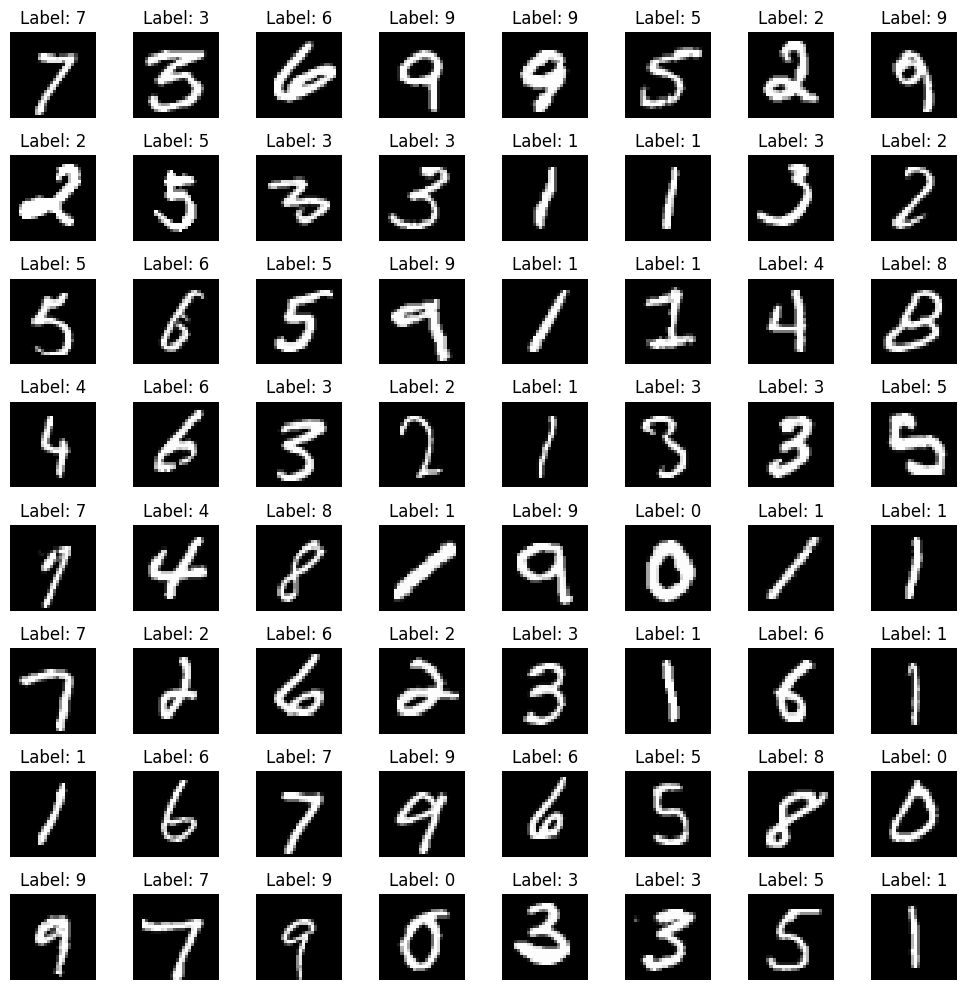

In [6]:
X, y = next(iter(train_dataloader))

print(X.shape)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
axes = axes.flatten()

for i in range(64):
    axes[i].imshow(X[i].permute(1, 2, 0), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Label: {y[i].item()}")

plt.tight_layout()
plt.show()

In [7]:
def plot_pair(img1, img2, label):
    # Converter tensor para valor
    label_value = int(label.item())

    # Definir título
    title = "Diferentes" if label_value == 1 else "Similares"

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(img1.squeeze(), cmap="gray")
    axes[0].axis("off")

    axes[1].imshow(img2.squeeze(), cmap="gray")
    axes[1].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.show()

In [8]:
train_siamesedataset = SiameseDataset(train_dataset)
train_siamese_dataloader = DataLoader(train_siamesedataset, batch_size=BATCH_SIZE, shuffle=True)
test_siamesedataset = SiameseDataset(test_dataset)
test_siamese_dataloader = DataLoader(test_siamesedataset, batch_size=BATCH_SIZE, shuffle=False)

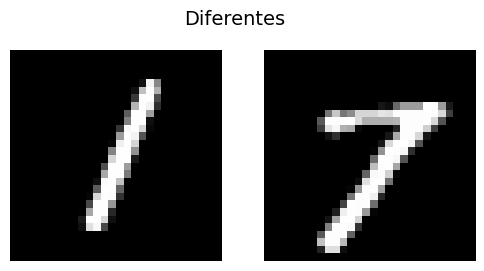

In [9]:
batch = next(iter(train_siamese_dataloader))
plot_pair(batch[0][0], batch[1][0], batch[2][0])


## 4 - Definição das arquiteturas

In [10]:
#Classifier = MLP(input_dim=len(train_dataset[0][0].squeeze().flatten()), output_dim = embedding_dim )
Classifier = LeNet(input_dim = len(train_dataset[0][0]), output_dim = embedding_dim)
#Classifier = AlexNet(input_dim = len(train_dataset[0][0]), output_dim = embedding_dim)

In [11]:
#Teste com um batch
Classifier.eval()
logits = Classifier(X)
logits[:10], logits.shape

(tensor([[-0.0587,  0.0883, -0.0878,  ..., -0.0804,  0.0052,  0.0829],
         [-0.0582,  0.0868, -0.0839,  ..., -0.0804,  0.0056,  0.0841],
         [-0.0610,  0.0898, -0.0871,  ..., -0.0752,  0.0046,  0.0845],
         ...,
         [-0.0555,  0.0838, -0.0852,  ..., -0.0823,  0.0043,  0.0824],
         [-0.0592,  0.0880, -0.0849,  ..., -0.0787,  0.0042,  0.0841],
         [-0.0588,  0.0896, -0.0810,  ..., -0.0798,  0.0018,  0.0812]],
        grad_fn=<SliceBackward0>),
 torch.Size([256, 128]))

In [12]:
#Definição do Modelo
model = SiameseNetwork(Classifier)


## 5 - Teste Inicial

In [13]:
#Criar uma pasta para o experimento

file = f"test/{model.__class__.__name__}/{Classifier.__class__.__name__}_{dataset}_{embedding_dim}_{LR}_{EPOCHS}/{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs("test", exist_ok=True)
os.makedirs(file, exist_ok=True)

In [14]:
def evaluate_embeddings(model, dataloader, title="Embedding Evaluation"):
    model.eval()

    pos = []
    neg = []

    with torch.no_grad():
        for batch in tqdm(dataloader):

            if len(batch) == 3:
                # Pode ser Siamese ou Triplet

                if isinstance(batch[2], torch.Tensor) and batch[2].ndim == 1:
                    # Siamese: (x1, x2, label)
                    x1, x2, label = batch

                    z1 = model.embed(x1)
                    z2 = model.embed(x2)

                    z1 = F.normalize(z1, dim=1)
                    z2 = F.normalize(z2, dim=1)

                    d = F.pairwise_distance(z1, z2).cpu().numpy()

                    pos.extend(d[label == 0])
                    neg.extend(d[label == 1])

                else:
                    # Triplet: (a, p, n)
                    a, p, n = batch

                    za = model.embed(a)
                    zp = model.embed(p)
                    zn = model.embed(n)

                    za = F.normalize(za, dim=1)
                    zp = F.normalize(zp, dim=1)
                    zn = F.normalize(zn, dim=1)

                    d_ap = F.pairwise_distance(za, zp).cpu().numpy()
                    d_an = F.pairwise_distance(za, zn).cpu().numpy()

                    pos.extend(d_ap)
                    neg.extend(d_an)

            else:
                raise ValueError("Formato de batch não suportado")

    pos = np.array(pos)
    neg = np.array(neg)

    # Plot
    plt.figure()
    plt.hist(pos, bins=50, alpha=0.5, label="similar", density=True)
    plt.hist(neg, bins=50, alpha=0.5, label="different", density=True)

    # Threshold ótimo
    all_dist = np.concatenate([pos, neg])
    thresholds = np.linspace(all_dist.min(), all_dist.max(), 200)

    accs = []
    for t in thresholds:
        tp = np.sum(pos < t)
        tn = np.sum(neg > t)
        acc = (tp + tn) / (len(pos) + len(neg))
        accs.append(acc)

    best_idx = np.argmax(accs)
    best_t = thresholds[best_idx]
    best_acc = accs[best_idx]

    plt.axvline(best_t, linestyle="--", label=f"thr={best_t:.2f}")
    plt.legend()
    plt.title(title)
    plt.show()

    # Métricas
    print(f"Separation: {(neg.mean() - pos.mean()):.4f}")
    print(f"Accuracy: {best_acc:.4f}")
    
    plt.savefig(os.path.join(file, title.replace(" ", "_").lower() + ".png"))

    return (neg.mean() - pos.mean()), best_acc

100%|██████████| 40/40 [00:04<00:00,  9.28it/s]


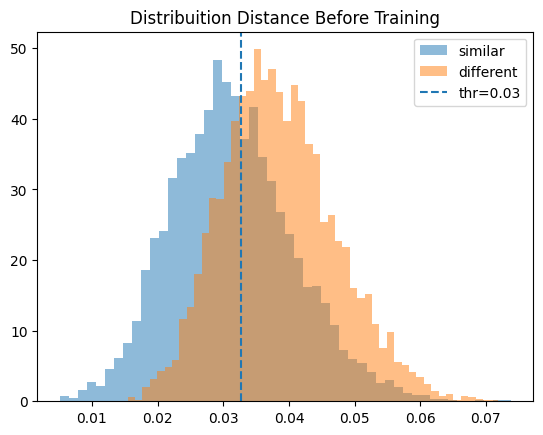

Separation: 0.0071
Accuracy: 0.6613


<Figure size 640x480 with 0 Axes>

In [15]:
sepration_pre_training, accuracy_pre_trainin = evaluate_embeddings(model, test_siamese_dataloader, title="Distribuition Distance Before Training")


## 6 - Pipeline de treinamento

In [16]:
def train_siamese(model, dataloader, optimizer, criterion, epochs, device):

    model.to(device)

    loss_history = []
    step = 0

    for epoch in range(epochs):

        model.train()

        for x1, x2, label in tqdm(dataloader):

            x1 = x1.to(device)
            x2 = x2.to(device)
            label = label.to(device)

            optimizer.zero_grad()

            z1, z2 = model(x1, x2)

            loss = criterion(z1, z2, label)

            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())

            step += 1

        tqdm.write(f"Processed {epoch+1}/{epochs} epochs")

    torch.save(model.backbone.state_dict(), f"{file}/model.pth")
    return loss_history

In [17]:
def train(model, dataloader, optimizer, epochs, device):

    model.to(device)
    loss_history = []

    for epoch in range(epochs):
        model.train()

        for batch in tqdm(dataloader):
            batch = [b.to(device) for b in batch]

            optimizer.zero_grad()

            loss = model.training_step(batch)

            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())

        tqdm.write(f"Processed {epoch+1}/{epochs}")

    return loss_history

In [18]:
criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

#loss = train_siamese(model, train_siamese_dataloader, optimizer, criterion, EPOCHS, DEVICE)
loss = train(model, train_siamese_dataloader, optimizer, EPOCHS, DEVICE)

100%|██████████| 235/235 [00:32<00:00,  7.29it/s]

Processed 1/1



## 6 - Pipeline de teste

In [19]:
#salvar loss curve
loss_df = pd.DataFrame({"loss": loss})
loss_df.to_csv(os.path.join(file, "loss_curve.csv"), index=False)

In [20]:
def plot_loss_curve(loss_history):

    plt.figure(figsize=(8,5))

    plt.plot(loss_history)

    plt.xlabel("Training Step")
    plt.ylabel("Contrastive Loss")
    plt.title("Training Loss Curve")

    plt.grid(True)
    plt.savefig(f"{file}/loss_curve.png")
    plt.show()

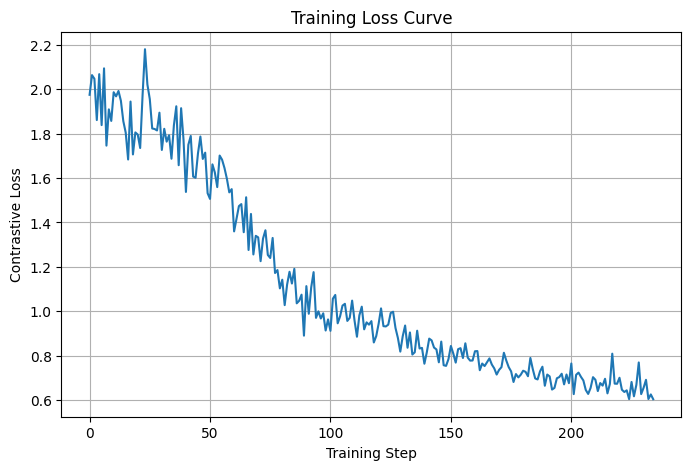

In [21]:
plot_loss_curve(loss)

100%|██████████| 40/40 [00:04<00:00,  8.42it/s]


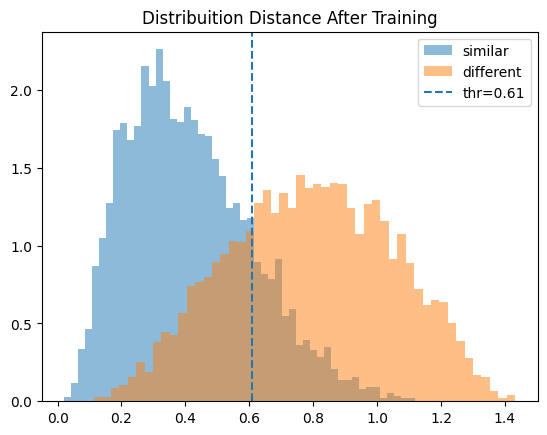

Separation: 0.3776
Accuracy: 0.7892


(np.float32(0.37755594), np.float64(0.7892))

<Figure size 640x480 with 0 Axes>

In [22]:
evaluate_embeddings(model, test_siamese_dataloader, title="Distribuition Distance After Training")


## 7 - Avaliação e visualização das representações

In [23]:
def get_embeddings(dataloader, model, device):
    model.eval()
    model.to(device)

    with torch.no_grad():
        embeddings = []
        labels = []

        for data, label in tqdm(dataloader):
            data = data.to(device)
            embedding = model.embed(data)
            embeddings.append(embedding.cpu().numpy())
            labels.append(label.cpu().numpy())

        return np.concatenate(embeddings, axis=0), np.concatenate(labels, axis=0)


In [24]:
def get_random_samples(data, labels, num_samples=2000):
    if len(data) > num_samples:
        idx = np.random.choice(len(data), num_samples, replace=False)
        data = data[idx]
        labels = labels[idx]

    return data, labels

In [25]:

def plot_tsne(data, labels, title="t-SNE visualization"):

    print("Running t-SNE...")

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
        
    data_2d = tsne.fit_transform(data)

    plt.figure(figsize=(8,8))

    scatter = plt.scatter(
        data_2d[:,0],
        data_2d[:,1],
        c=labels,
        cmap="tab10",
        s=10
    )

    plt.colorbar(scatter)

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.grid(True)
    plt.savefig(f"{file}/{title}.png")
    plt.show()

In [26]:
test_samples = get_random_samples(test_dataset.data, test_dataset.targets, num_samples=2000)

embeddings_samples = get_embeddings(test_dataloader, model, DEVICE)
embeddings_samples = get_random_samples(embeddings_samples[0], embeddings_samples[1], num_samples=2000)

100%|██████████| 40/40 [00:01<00:00, 21.05it/s]


Running t-SNE...


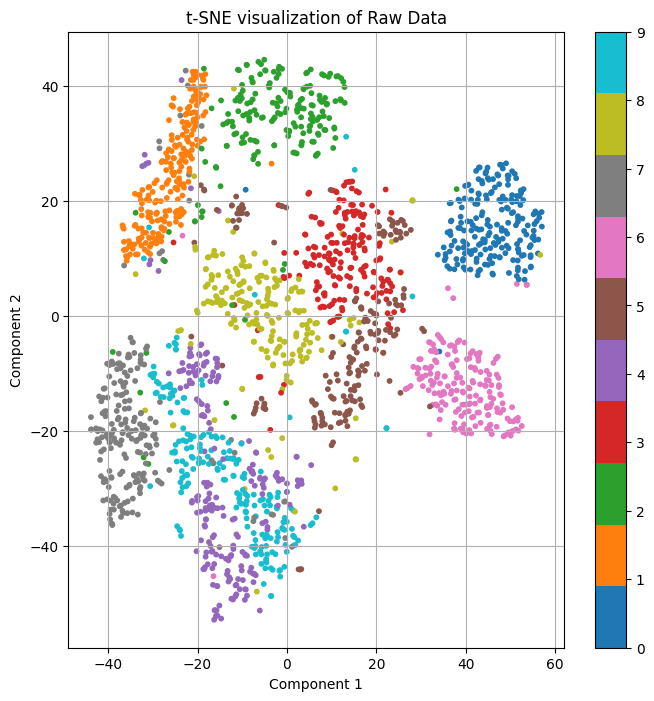

Running t-SNE...


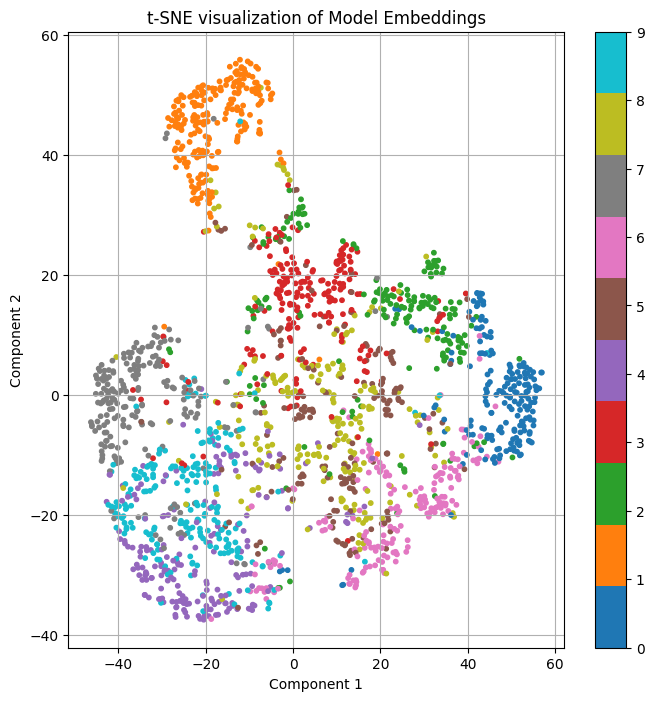

In [27]:
plot_tsne(test_samples[0], test_samples[1], title="t-SNE visualization of Raw Data")
plot_tsne(embeddings_samples[0], embeddings_samples[1], title="t-SNE visualization of Model Embeddings")